In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
start = '2015-01-01'
end = '2025-12-31'

df  = yf.download('AAPL', start=start, end=end)
df.head()

/tmp/ipykernel_758/3283356595.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df  = yf.download('AAPL', start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2015-01-06,23.534941,23.794077,23.173920,23.596956,263188400
2015-01-07,23.864954,23.964621,23.632395,23.743137,160423600
2015-01-08,24.781895,24.839481,24.075359,24.192747,237458000


In [ ]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
1,2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2,2015-01-06,23.534941,23.794077,23.173920,23.596956,263188400
3,2015-01-07,23.864954,23.964621,23.632395,23.743137,160423600
4,2015-01-08,24.781895,24.839481,24.075359,24.192747,237458000


In [ ]:
df = df.drop(['Date'], axis = 1)
df.head()

/tmp/ipykernel_758/3502562368.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date'], axis = 1)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,24.214891,24.682224,23.776352,24.671149,212818400
1,23.532722,24.064285,23.346676,23.984551,257142000
2,23.534941,23.794077,23.173920,23.596956,263188400
3,23.864954,23.964621,23.632395,23.743137,160423600
4,24.781895,24.839481,24.075359,24.192747,237458000


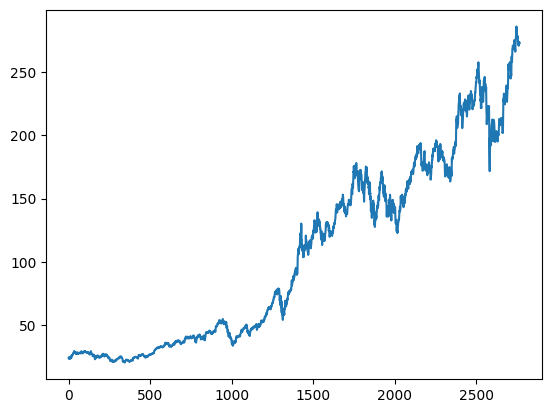

In [ ]:
plt.plot(df.Close)

In [ ]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,24.214891,24.682224,23.776352,24.671149,212818400
1,23.532722,24.064285,23.346676,23.984551,257142000
2,23.534941,23.794077,23.173920,23.596956,263188400
3,23.864954,23.964621,23.632395,23.743137,160423600
4,24.781895,24.839481,24.075359,24.192747,237458000
...,...,...,...,...,...
2760,272.105377,272.245261,269.308007,270.586809,29642000
2761,273.554016,275.172497,271.945536,272.085389,17910600
2762,273.144409,275.112569,272.604905,273.903708,21521800


In [ ]:
ma100 = df.Close.rolling(100).mean()
ma100
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2760,229.717952
2761,229.986314
2762,230.271843
2763,230.595514


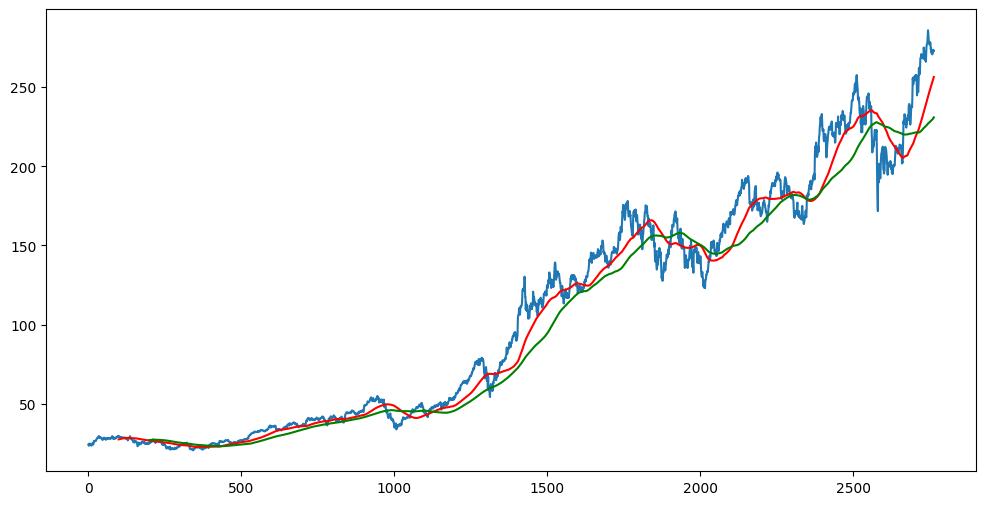

In [ ]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

In [ ]:
df.shape

(2765, 5)

In [ ]:
# Splitting Data into Training and Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(1935, 1)
(830, 1)


In [ ]:
data_training.head()

Ticker,AAPL
0,24.214891
1,23.532722
2,23.534941
3,23.864954
4,24.781895


In [ ]:
data_testing.head()

Ticker,AAPL
1935,154.629730
1936,160.584198
1937,151.161179
1938,152.605606
1939,149.716782


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [ ]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.02304533],
       [0.01871462],
       [0.0187287 ],
       ...,
       [0.83326149],
       [0.84218173],
       [0.8328251 ]])

In [ ]:
data_training_array.shape

(1935, 1)

In [ ]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [ ]:
# ML Model

In [ ]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [ ]:
model = Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - loss: 0.0392
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 243ms/step - loss: 0.0089
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 263ms/step - loss: 0.0061
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - loss: 0.0080
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 243ms/step - loss: 0.0063
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 242ms/step - loss: 0.0055
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - loss: 0.0044
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 242ms/step - loss: 0.0046
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 242ms/step - loss: 0.0054
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - loss: 0.0043
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - loss: 0.0045
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - loss: 0.0041
Epoch 13/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - loss: 0.0045
Epoch 14/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - loss: 0.0046
Epoch 15/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 

In [ ]:
model.save('my_model.keras')

In [ ]:
data_testing.head()

Ticker,AAPL
1935,154.629730
1936,160.584198
1937,151.161179
1938,152.605606
1939,149.716782


In [ ]:
past_100_days = data_training.tail(100)

In [ ]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [ ]:
final_df.head()

Ticker,AAPL
0,161.733063
1,164.015930
2,163.849350
3,163.055756
4,158.519318


In [ ]:
input_data = scaler.fit_transform(final_df)
input_data

array([[2.37520199e-01],
       [2.51536213e-01],
       [2.50513469e-01],
       [2.45641074e-01],
       [2.17788918e-01],
       [2.24346026e-01],
       [1.87771639e-01],
       [1.86388025e-01],
       [2.28917695e-01],
       [1.92884800e-01],
       [1.94749667e-01],
       [2.03893100e-01],
       [2.43234809e-01],
       [1.87591110e-01],
       [1.92048954e-01],
       [1.60602062e-01],
       [1.75361550e-01],
       [1.27106308e-01],
       [1.03370237e-01],
       [1.30781143e-01],
       [1.21322840e-01],
       [1.43613090e-01],
       [9.28880648e-02],
       [7.19833963e-02],
       [7.34289353e-02],
       [1.06683829e-01],
       [9.01166207e-02],
       [9.10806257e-02],
       [1.10720096e-01],
       [1.46022821e-01],
       [1.41203452e-01],
       [1.40420163e-01],
       [1.55481125e-01],
       [1.20359022e-01],
       [1.24937624e-01],
       [1.40420163e-01],
       [1.35901799e-01],
       [1.03852427e-01],
       [7.06579596e-02],
       [3.90299768e-02],


In [ ]:
input_data.shape

(930, 1)

In [ ]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [ ]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(830, 100, 1)
(830,)


In [ ]:
# Making Predictions

y_predicted = model.predict(x_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step


In [ ]:
y_predicted.shape

(830, 1)

In [ ]:
y_test

array([1.93908200e-01, 2.30466568e-01, 1.72612496e-01, 1.81480780e-01,
       1.63744400e-01, 1.53669657e-01, 1.76473481e-01, 1.91072677e-01,
       1.71888696e-01, 1.65976507e-01, 1.52040967e-01, 1.54091983e-01,
       1.60064411e-01, 1.48481549e-01, 1.04080547e-01, 7.82603897e-02,
       1.03899644e-01, 1.25919242e-01, 1.27728929e-01, 1.21877260e-01,
       8.96623486e-02, 9.16531266e-02, 8.29660270e-02, 7.91049481e-02,
       1.07157400e-01, 7.93462772e-02, 1.03658221e-01, 1.11742373e-01,
       1.12405747e-01, 1.09570504e-01, 1.32977463e-01, 1.46128684e-01,
       1.63563590e-01, 1.45525548e-01, 1.18076513e-01, 1.84074787e-01,
       1.69596257e-01, 1.53367996e-01, 1.19463968e-01, 8.23626104e-02,
       8.07311093e-02, 8.39942053e-02, 8.74990052e-02, 5.95212193e-02,
       1.32034069e-01, 1.49135180e-01, 1.40554318e-01, 1.51189757e-01,
       1.43636230e-01, 1.55298723e-01, 1.58743003e-01, 1.38922817e-01,
       1.52035627e-01, 1.57413819e-01, 1.39527170e-01, 1.16020812e-01,
      

In [ ]:
y_predicted

array([[0.30935064],
       [0.30290252],
       [0.29599363],
       [0.28890005],
       [0.28186166],
       [0.27495056],
       [0.2681098 ],
       [0.26137596],
       [0.25475228],
       [0.24809998],
       [0.2414857 ],
       [0.23500562],
       [0.2288145 ],
       [0.22314769],
       [0.2180118 ],
       [0.21326831],
       [0.20881371],
       [0.20456252],
       [0.20046258],
       [0.19653818],
       [0.1928516 ],
       [0.18937582],
       [0.1860605 ],
       [0.1828393 ],
       [0.17966187],
       [0.17656213],
       [0.17353755],
       [0.17064326],
       [0.16795635],
       [0.16553424],
       [0.16342156],
       [0.16167538],
       [0.16034271],
       [0.15950993],
       [0.15919851],
       [0.15931897],
       [0.15989411],
       [0.16092415],
       [0.16236475],
       [0.16410103],
       [0.16594547],
       [0.16770184],
       [0.16919515],
       [0.17029189],
       [0.17087127],
       [0.17096001],
       [0.17065823],
       [0.170

In [ ]:
scaler.scale_

array([0.00613965])

In [ ]:
scale_factor = 1/0.020
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor

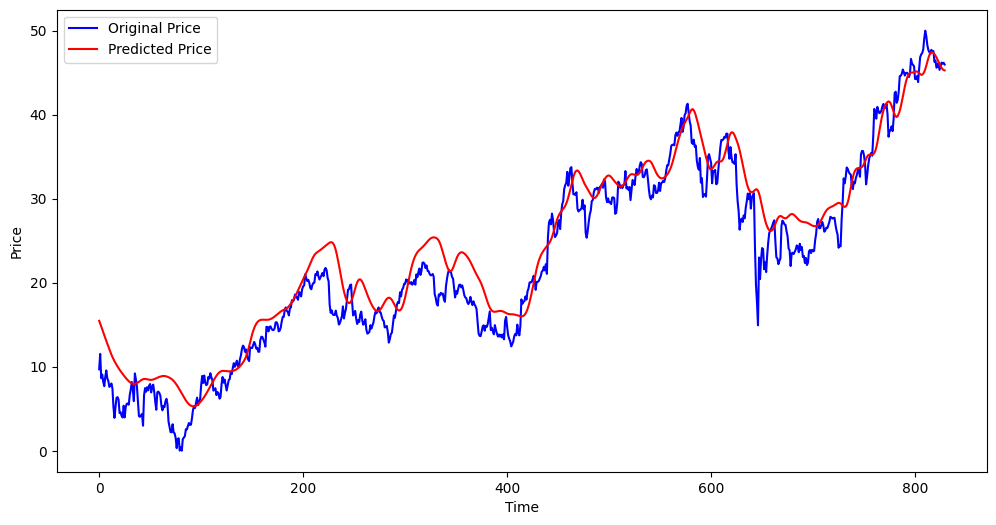

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label = 'Original Price')
plt.plot(y_predicted, 'r', label = 'Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()